In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score

# Cấu hình giao diện đồ thị và font chữ hiển thị tiếng Việt
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")
print("--- CELL 1: Khởi tạo môi trường thành công ---")

--- CELL 1: Khởi tạo môi trường thành công ---


In [32]:
# Đọc tập dữ liệu
df = pd.read_csv('vietnam_jobs_dataset.csv')

# Xử lý làm sạch và tính toán các trường số học
df['salary_numeric'] = (df['salary_min'] + df['salary_max']) / 2
df['exp_numeric'] = df['experience'].str.extract(r'(\d+)').astype(float).fillna(0)

# Loại bỏ các dòng tuyển dụng thiếu thông tin lương
df_clean = df.dropna(subset=['salary_numeric']).reset_index(drop=True)
print(f"--- CELL 2: Làm sạch dữ liệu thành công. Tổng số bản ghi phân tích: {df_clean.shape[0]} ---")

--- CELL 2: Làm sạch dữ liệu thành công. Tổng số bản ghi phân tích: 85470 ---


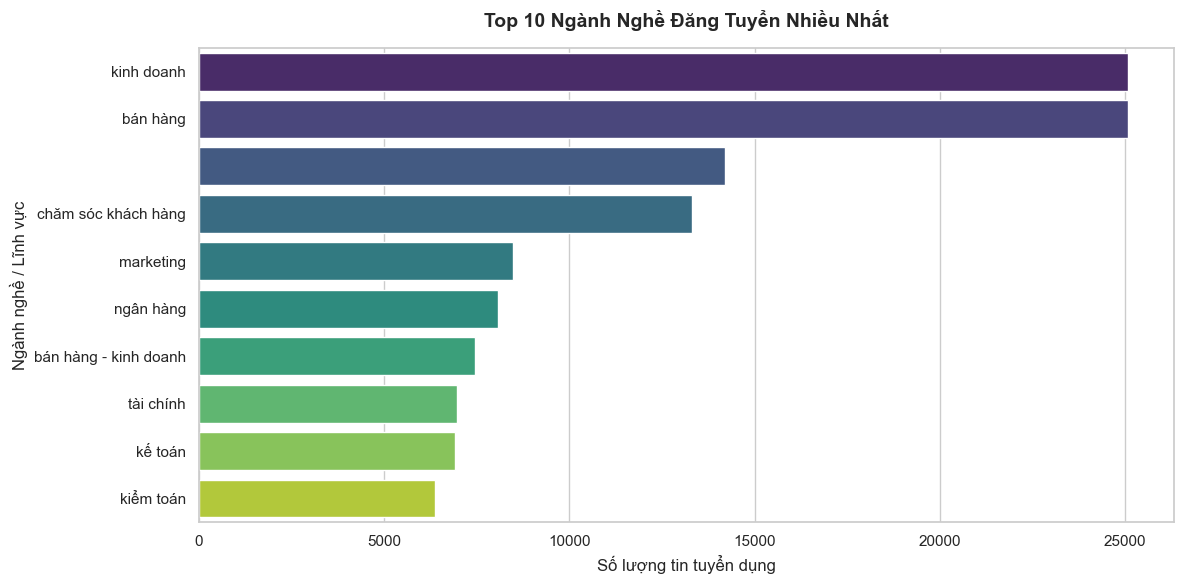

In [33]:
# Ngành nghề nào được tuyển dụng nhiều nhất?
plt.figure(figsize=(12, 6))

# Tách nhỏ các ngành nghề bị gộp chung bởi dấu phẩy và đếm tần suất
exploded_fields = df_clean['job_fields'].str.split(',').explode().str.strip() #
top_fields = exploded_fields.value_counts().head(10)

sns.barplot(x=top_fields.values, y=top_fields.index, hue=top_fields.index, palette='viridis', legend=False)
plt.title('Top 10 Ngành Nghề Đăng Tuyển Nhiều Nhất', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số lượng tin tuyển dụng')
plt.ylabel('Ngành nghề / Lĩnh vực')
plt.tight_layout()
plt.show()

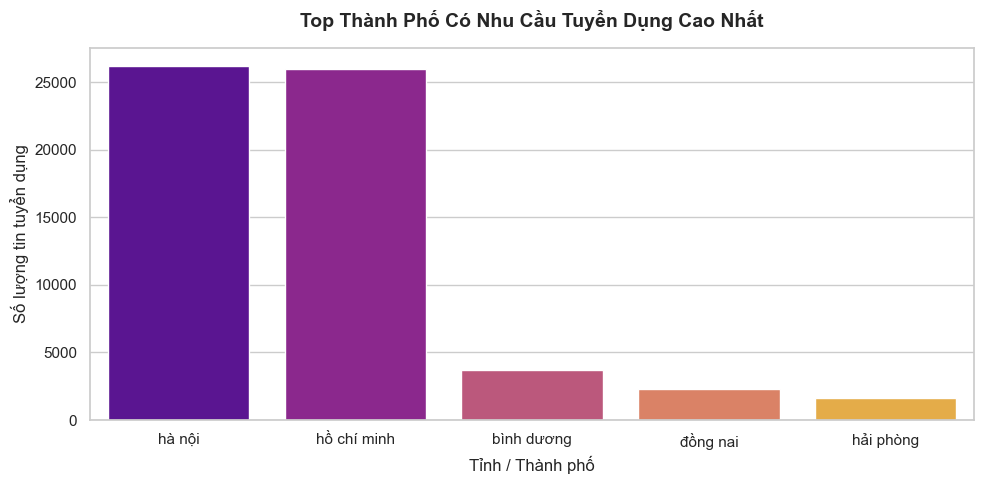

In [34]:
# Thành phố nào có nhu cầu tuyển dụng cao nhất?
plt.figure(figsize=(10, 5))

# Lấy top các địa điểm tập trung nhiều tin tuyển dụng nhất
top_cities = df_clean['city'].value_counts().head(5)

sns.barplot(x=top_cities.index, y=top_cities.values, hue=top_cities.index, palette='plasma', legend=False)
plt.title('Top Thành Phố Có Nhu Cầu Tuyển Dụng Cao Nhất', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỉnh / Thành phố')
plt.ylabel('Số lượng tin tuyển dụng')
plt.tight_layout()
plt.show()

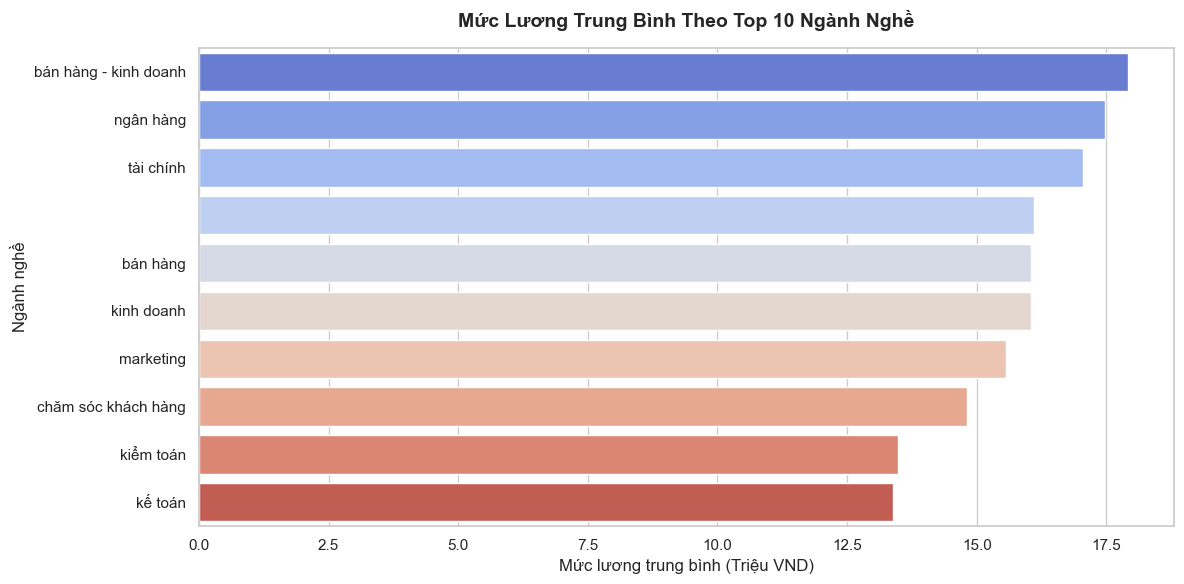

In [35]:
# Mức lương trung bình theo top 10 ngành nghề?
plt.figure(figsize=(12, 6))

# Phân rã ngành nghề gắn liền với mức lương tương ứng
df_exploded = df_clean.assign(job_fields=df_clean['job_fields'].str.split(',')).explode('job_fields')
df_exploded['job_fields'] = df_exploded['job_fields'].str.strip()

# Thống kê mức lương trung bình của top 10 ngành phổ biến nhất
top_10_fields = df_exploded['job_fields'].value_counts().head(10).index
df_top_salary = df_exploded[df_exploded['job_fields'].isin(top_10_fields)]
field_salary_mean = df_top_salary.groupby('job_fields')['salary_numeric'].mean().sort_values(ascending=False)

sns.barplot(x=field_salary_mean.values, y=field_salary_mean.index, hue=field_salary_mean.index, palette='coolwarm', legend=False)
plt.title('Mức Lương Trung Bình Theo Top 10 Ngành Nghề', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mức lương trung bình (Triệu VND)')
plt.ylabel('Ngành nghề')
plt.tight_layout()
plt.show()

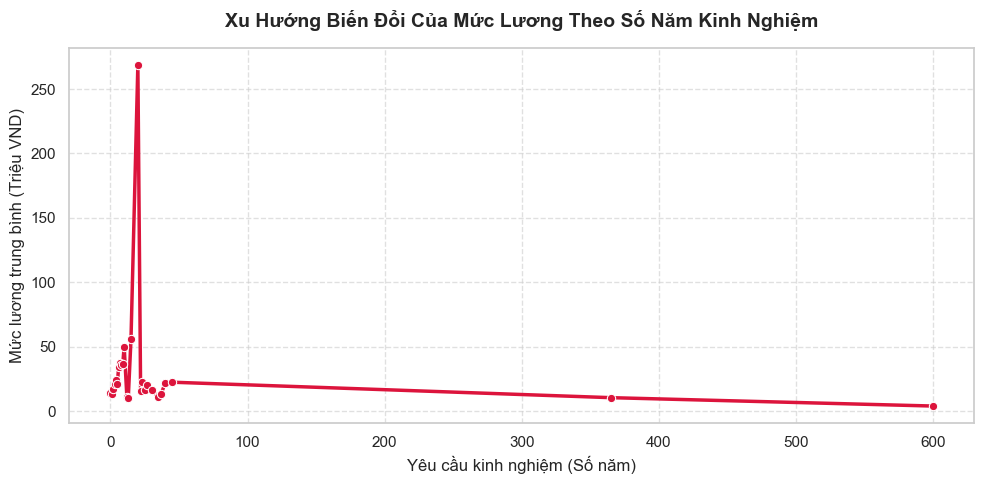

In [36]:
# Xu hướng lương biến đổi theo kinh nghiệm?
plt.figure(figsize=(10, 5))

# Nhóm theo năm kinh nghiệm số để tính mức lương trung bình xu hướng
exp_trend = df_clean.groupby('exp_numeric')['salary_numeric'].mean().reset_index()

sns.lineplot(x='exp_numeric', y='salary_numeric', data=exp_trend, marker='o', color='crimson', linewidth=2.5)
plt.title('Xu Hướng Biến Đổi Của Mức Lương Theo Số Năm Kinh Nghiệm', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Yêu cầu kinh nghiệm (Số năm)')
plt.ylabel('Mức lương trung bình (Triệu VND)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [37]:
# Phân phối lương theo cấp bậc vị trí?
print("--- CÂU 5: BẢNG PIVOT THỐNG KÊ LƯƠNG THEO CẤP BẬC VỊ TRÍ ---")

# Tạo bảng Pivot Table thống kê phân phối lương theo cấp bậc
pivot_position = df_clean.pivot_table(
    values='salary_numeric',
    index='position_level',
    aggfunc=['mean', 'min', 'max']
).rename(columns={'mean': 'Lương Trung Bình', 'min': 'Lương Thấp Nhất', 'max': 'Lương Cao Nhất'})

display(pivot_position)

--- CÂU 5: BẢNG PIVOT THỐNG KÊ LƯƠNG THEO CẤP BẬC VỊ TRÍ ---


,Lương Trung Bình,Lương Thấp Nhất,Lương Cao Nhất
,salary_numeric,salary_numeric,salary_numeric
position_level,,,
,65.000000,65.00,65.0
Nhân viên,15.142857,11.50,17.5
chuyên gia,17.284314,6.50,35.0
"chuyên viên, nhân viên",15.678330,1.50,318.0
chưa cập nhật,8.500000,8.50,8.5
cộng tác viên,13.500385,0.55,68.0
error,13.750000,13.50,14.0
giám đốc,42.563783,10.00,237.5


--- CÂU 6: MÔ HÌNH HỌC MÁY DỰ ĐOÁN MỨC LƯƠNG (RANDOM FOREST) ---

[KẾT LUẬN]: CÓ THỂ DỰ ĐOÁN ĐƯỢC từ các thông tin công việc đầu vào.
   - Sai số trung bình RMSE: 11.53 Triệu VND
   - Hệ số xác định R² Score (Độ chính xác giải thích): 0.1378



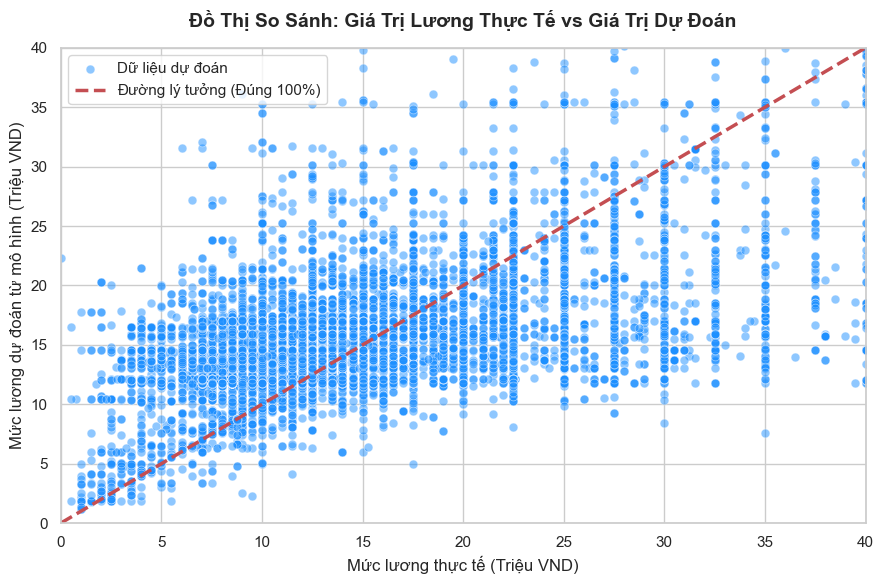

In [38]:
# Mức lương của một vị trí tuyển dụng có thể được dự đoán từ các thông tin tuyển dụng hay không?
print("--- CÂU 6: MÔ HÌNH HỌC MÁY DỰ ĐOÁN MỨC LƯƠNG (RANDOM FOREST) ---")

# 1. Lựa chọn các thuộc tính công việc làm biến độc lập đầu vào
features = ['job_type', 'position_level', 'city', 'exp_numeric']
X = df_clean[features].copy()
y = df_clean['salary_numeric']

# 2. Mã hóa định dạng danh mục chữ sang số
for col in ['job_type', 'position_level', 'city']:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str)) ##

# 3. Chia tập dữ liệu (80% Train / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Khởi tạo và huấn luyện mô hình Học máy Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) ##
model_rf.fit(X_train, y_train)

# 5. Dự đoán và tính toán sai số, hiệu năng
y_pred = model_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n[KẾT LUẬN]: CÓ THỂ DỰ ĐOÁN ĐƯỢC từ các thông tin công việc đầu vào.")
print(f"   - Sai số trung bình RMSE: {rmse:.2f} Triệu VND")
print(f"   - Hệ số xác định R² Score (Độ chính xác giải thích): {r2:.4f}\n")

# =========================================================================
# BỔ SUNG: ĐOẠN CODE VẼ BIỂU ĐỒ TRỰC QUAN HÓA (THỰC TẾ VS DỰ ĐOÁN)
# =========================================================================
plt.figure(figsize=(9, 6))

# Vẽ các điểm chấm thể hiện kết quả dự đoán đối chiếu thực tế
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='dodgerblue', edgecolor='w', s=40, label='Dữ liệu dự đoán')

# Đường chéo nét đứt màu đỏ chuẩn (Nếu dự đoán đúng 100%, các chấm sẽ nằm hoàn toàn trên đường này)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Đường lý tưởng (Đúng 100%)')

# Giới hạn trục hiển thị để biểu đồ gọn đẹp, tập trung vào phân khúc lương phổ biến
plt.xlim(0, df_clean['salary_numeric'].quantile(0.98))
plt.ylim(0, df_clean['salary_numeric'].quantile(0.98))

plt.title('Đồ Thị So Sánh: Giá Trị Lương Thực Tế vs Giá Trị Dự Đoán', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mức lương thực tế (Triệu VND)', fontsize=12)
plt.ylabel('Mức lương dự đoán từ mô hình (Triệu VND)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()

# Xuất ảnh lưu lại bài làm
plt.savefig('ml_du_doan_luong.png', dpi=300)
plt.show()

--- CÂU 7: PHÂN CỤM THỊ TRƯỜNG VIỆC LÀM (K-MEANS CLUSTERING) ---


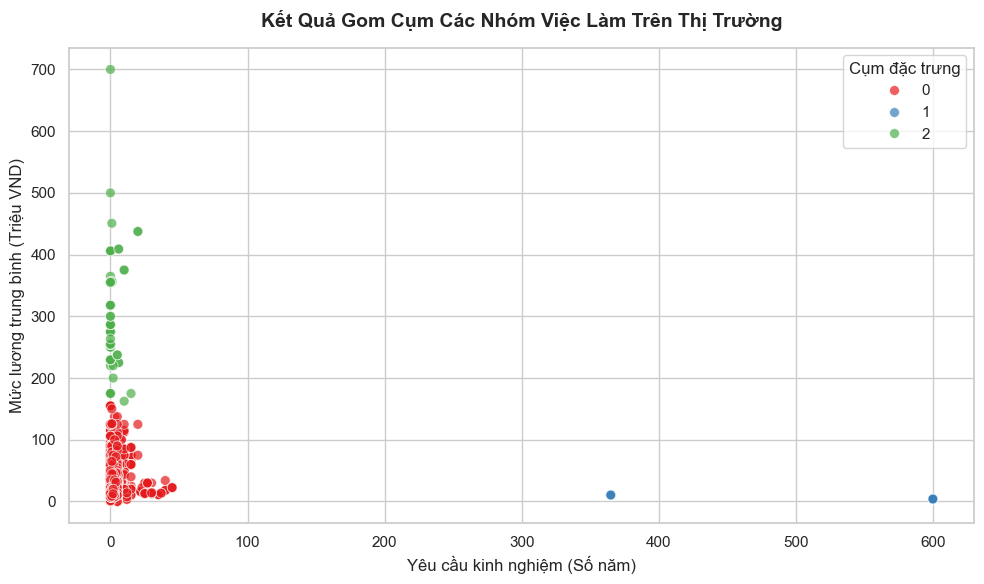


[BẢNG THÔNG SỐ ĐẶC TRƯNG CHI TIẾT CỦA TỪNG CỤM VIỆC LÀM]:


salary_numeric               exp_numeric              
                  mean    min    max        mean    min    max
cluster                                                       
0            15.316835    0.0  155.0    1.080283    0.0   45.0
1             6.785714    4.0   10.5  499.285714  365.0  600.0
2           301.503846  162.5  700.0    1.953846    0.0   20.0

In [40]:
# Phân cụm thị trường việc làm theo lương & kinh nghiệm?
print("--- CÂU 7: PHÂN CỤM THỊ TRƯỜNG VIỆC LÀM (K-MEANS CLUSTERING) ---")

# Lấy các trường dữ liệu định lượng phục vụ phân cụm
cluster_data = df_clean[['salary_numeric', 'exp_numeric']].dropna()

# Chuẩn hóa dữ liệu về cùng thang đo chuẩn Z-Score
scaled_features = StandardScaler().fit_transform(cluster_data)

# Phân tách thị trường thành 3 nhóm đặc trưng tương đồng độc lập
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans_model.fit_predict(scaled_features)

# Trực quan hóa bản đồ phân cụm bằng biểu đồ Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='exp_numeric', y='salary_numeric', hue='cluster', data=df_clean, palette='Set1', alpha=0.7, s=50)
plt.title('Kết Quả Gom Cụm Các Nhóm Việc Làm Trên Thị Trường', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Yêu cầu kinh nghiệm (Số năm)')
plt.ylabel('Mức lương trung bình (Triệu VND)')
plt.legend(title='Cụm đặc trưng')
plt.tight_layout()
plt.show()

# Xuất thông số thống kê bản chất chi tiết của từng cụm
print("\n[BẢNG THÔNG SỐ ĐẶC TRƯNG CHI TIẾT CỦA TỪNG CỤM VIỆC LÀM]:")
display(df_clean.groupby('cluster')[['salary_numeric', 'exp_numeric']].agg(['mean', 'min', 'max']))